In [4]:
import pandas as pd

In [5]:
training_set = pd.read_csv('../dataset/train.csv')
testing_set  = pd.read_csv('../dataset/test.csv')


In [6]:
training_set.shape

(42000, 785)

In [7]:
testing_set.shape

(28000, 784)

In [8]:
target = 'label'

With the Pca 

Normaling scaling of the dataset

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

training_set_scaled = scaler.fit_transform(training_set.drop(columns=target))
testing_set_scaled = scaler.transform(testing_set)

In [10]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=None
)
training_set_transformed=pca.fit_transform(training_set_scaled)
testing_set_transformed =pca.transform(testing_set_scaled)

In [13]:
pca.explained_variance_

array([4.06964787e+01, 2.91114657e+01, 2.67833371e+01, 2.08147194e+01,
       1.81000206e+01, 1.57876737e+01, 1.38244007e+01, 1.25432643e+01,
       1.10638975e+01, 1.00889267e+01, 9.63617203e+00, 8.65579470e+00,
       8.04120472e+00, 7.88086691e+00, 7.43637560e+00, 7.16743699e+00,
       6.73538375e+00, 6.61651973e+00, 6.42354578e+00, 6.26826675e+00,
       5.93960379e+00, 5.74928832e+00, 5.48826880e+00, 5.32649477e+00,
       5.15217038e+00, 4.94730998e+00, 4.88853571e+00, 4.70777145e+00,
       4.46528559e+00, 4.36351702e+00, 4.32543150e+00, 4.22712324e+00,
       4.08726514e+00, 4.06176768e+00, 3.99903435e+00, 3.86804997e+00,
       3.81925839e+00, 3.71256507e+00, 3.57437538e+00, 3.45887625e+00,
       3.41436841e+00, 3.36945857e+00, 3.25693182e+00, 3.24008824e+00,
       3.18312949e+00, 3.16286640e+00, 3.14244041e+00, 3.09287815e+00,
       3.06368054e+00, 3.02342271e+00, 2.96849737e+00, 2.91830693e+00,
       2.84948896e+00, 2.82806029e+00, 2.79589667e+00, 2.76696531e+00,
      

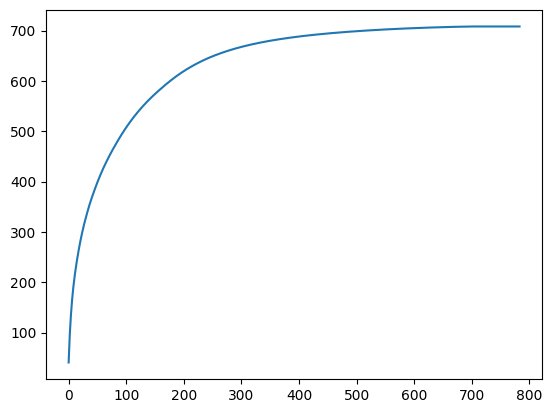

In [14]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(np.cumsum(pca.explained_variance_))

from the rule of thumb we can conclude that the model at number of component performs better at the PC of numbers 275

In [15]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=275
)
training_set_transformed=pca.fit_transform(training_set_scaled)
testing_set_transformed =pca.transform(testing_set_scaled)

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:
kn_clf = KNeighborsClassifier()
kn_clf.fit(training_set_transformed , training_set[target])

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
predicted=kn_clf.predict(testing_set_transformed)

In [19]:
predicted.shape

(28000,)

Testing the predictions with the given labels

In [20]:
predicted

array([2, 0, 9, ..., 3, 9, 2], shape=(28000,))

In [22]:
# import matplotlib.pyplot as plt
# for i in range(predicted.shape[0]):
#     plt.imshow(testing_set.iloc[i,:].values.reshape(28,28))
#     plt.title(f"predicted value{predicted[i]}")
#     plt.savefig(f"../predicted_images_with_pca//image{i}.png")